Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
import statsmodels.api as sm



Load Datasets and convert to Datetime

In [2]:

model_data = pd.read_csv('main_data/cbt/C01.csv')
model_data['timestamp'] = pd.to_datetime(model_data['timestamp'] , unit='s')


Temperature Start Core Body temperature


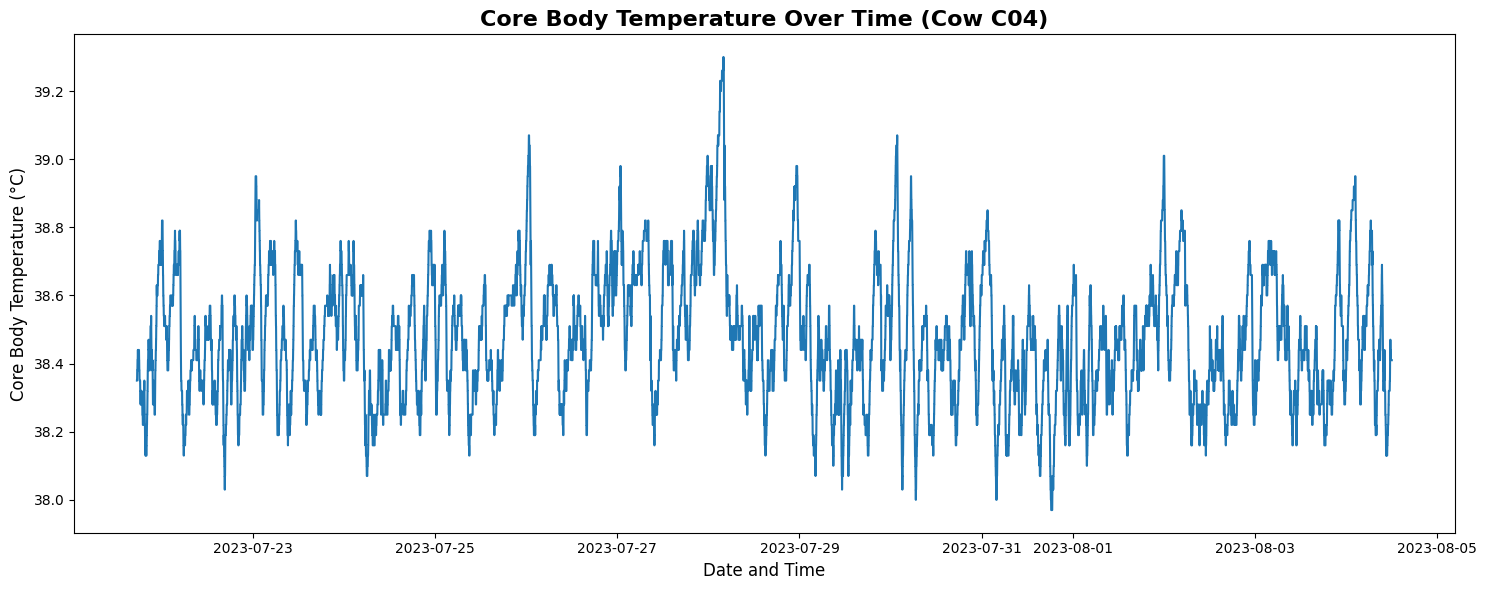

In [3]:


plt.figure(figsize=(15, 6)) 
plt.plot(model_data['timestamp'], model_data['temperature_C'])
plt.title('Core Body Temperature Over Time (Cow C04)', fontsize=16, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Core Body Temperature (°C)', fontsize=12)
plt.tight_layout()
plt.show()

Looking at change Variable and calculating it with a rolling average of 30 min Hier ist rolling window fine aber nur für visualization 


                     temperature_C  temp_change  temp_change_smooth
timestamp                                                          
2023-07-21 17:30:00          38.35          NaN                 NaN
2023-07-21 17:31:00          38.35         0.00              0.0000
2023-07-21 17:32:00          38.35         0.00              0.0000
2023-07-21 17:33:00          38.35         0.00              0.0000
2023-07-21 17:34:00          38.38         0.03              0.0075


C:\Users\Admin\AppData\Local\Temp\ipykernel_23928\3834700427.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  model_data['temp_change_smooth'] = model_data['temp_change'].rolling(window='30T').mean()


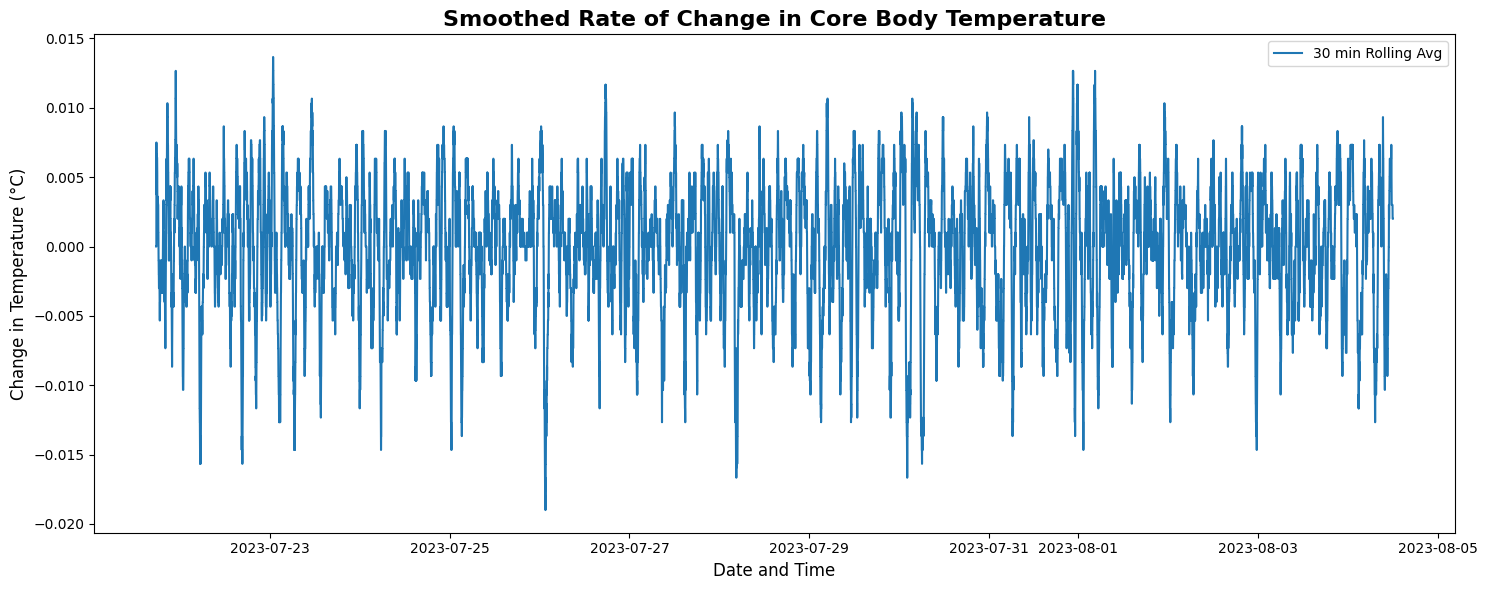

In [4]:

model_data['temp_change'] = model_data['temperature_C'].diff()
model_data = model_data.set_index('timestamp')
model_data['temp_change_smooth'] = model_data['temp_change'].rolling(window='30T').mean()
print(model_data.head())

plt.figure(figsize=(15, 6))
plt.plot(model_data.index, model_data['temp_change_smooth'], label='30 min Rolling Avg')
plt.title('Smoothed Rate of Change in Core Body Temperature', fontsize=16, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Change in Temperature (°C)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

model_data = model_data.reset_index()

Model without rolling average nor GLLA

In [5]:

baseline_data = model_data.dropna(subset=['temperature_C', 'temp_change']).copy()
baseline_data['temp_centered'] = baseline_data['temperature_C'] - baseline_data['temperature_C'].mean()
y_raw = baseline_data['temp_change']
x1_raw = baseline_data['temp_centered']
X_raw = np.column_stack((x1_raw, x1_raw**2))
X_raw = sm.add_constant(X_raw)
res_raw = sm.OLS(y_raw, X_raw).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(res_raw.summary())

                            OLS Regression Results                            
Dep. Variable:            temp_change   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     16.87
Date:                Fri, 15 May 2026   Prob (F-statistic):           4.77e-08
Time:                        13:42:02   Log-Likelihood:                 54867.
No. Observations:               19830   AIC:                        -1.097e+05
Df Residuals:                   19827   BIC:                        -1.097e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      1.043      0.2

Used to split the data every 30 points because of the rolling windo Durbin Watson better now too p values still significant

GLLA Check

In [6]:
from scipy.signal import savgol_filter
import statsmodels.api as sm
import numpy as np

window_size = 21 
poly_order = 2    
model_data['velocity_GLLA'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=1)
model_data['temp_GLLA'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=0)
model_data['temp_centered_GLLA'] = model_data['temp_GLLA'] - model_data['temp_GLLA'].mean()
glla_data = model_data.dropna(subset=['velocity_GLLA', 'temp_centered_GLLA']).copy()
y_glla = glla_data['velocity_GLLA']
x_glla = glla_data['temp_centered_GLLA']
X_glla = np.column_stack((x_glla, x_glla**2))
X_glla = sm.add_constant(X_glla)
res_glla = sm.OLS(y_glla, X_glla).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print(res_glla.summary())

                            OLS Regression Results                            
Dep. Variable:          velocity_GLLA   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.02389
Date:                Fri, 15 May 2026   Prob (F-statistic):              0.976
Time:                        13:42:02   Log-Likelihood:                 74702.
No. Observations:               19831   AIC:                        -1.494e+05
Df Residuals:                   19828   BIC:                        -1.494e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.68e-05      0.000      0.147      0.8

In [7]:
window_size = 21
poly_order = 3
model_data['accel_GLLA2'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=2)
model_data['velocity_GLLA2'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=1)
model_data['temp_GLLA2'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=0)
model_data['temp_centered_GLLA2'] = model_data['temp_GLLA2'] - model_data['temp_GLLA2'].mean()
glla_data = model_data.dropna(subset=['accel_GLLA2', 'velocity_GLLA2', 'temp_centered_GLLA2']).copy()
y_glla = glla_data['accel_GLLA2']
x_pos = glla_data['temp_centered_GLLA2']
x_vel = glla_data['velocity_GLLA2']
X_glla = np.column_stack((x_pos, x_pos**2, x_vel, x_vel**2))
X_glla = sm.add_constant(X_glla)
res_glla = sm.OLS(y_glla, X_glla).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print(res_glla.summary())

                            OLS Regression Results                            
Dep. Variable:            accel_GLLA2   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     81.98
Date:                Fri, 15 May 2026   Prob (F-statistic):           3.84e-69
Time:                        13:42:02   Log-Likelihood:             1.1478e+05
No. Observations:               19831   AIC:                        -2.295e+05
Df Residuals:                   19826   BIC:                        -2.295e+05
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.693e-05   1.53e-05     -1.759      0.0

Calculated Set Points: [43.96173366 38.48450808]


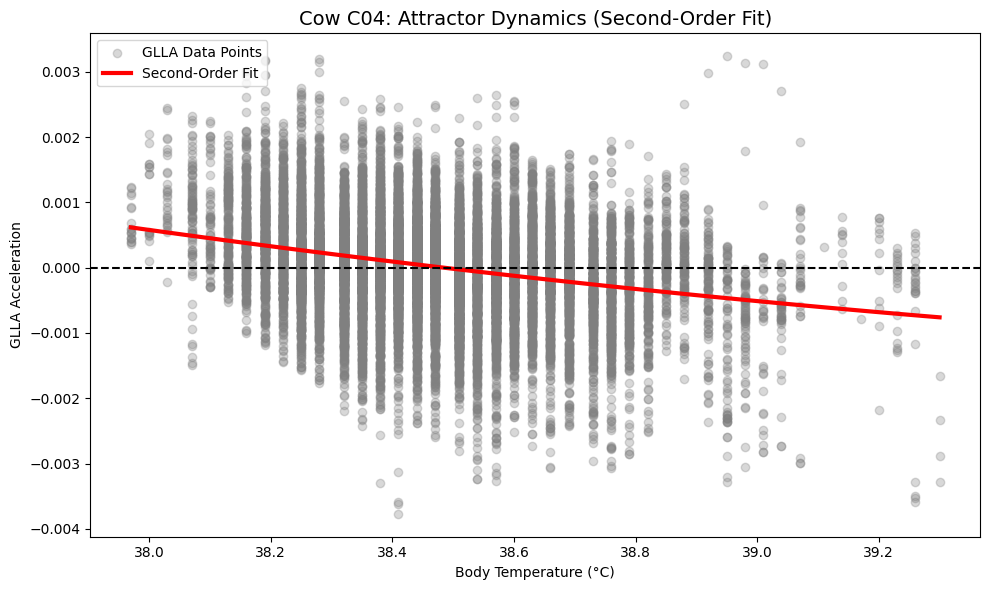

In [8]:
c, b1, b2 = 1.25e-05, -0.0011, 0.0002
roots = np.roots([b2, b1, c])
real_roots = roots[np.isreal(roots)].real
avg_temp = model_data['temperature_C'].mean()
set_points = real_roots + avg_temp
print(f"Calculated Set Points: {set_points}")
plt.figure(figsize=(10, 6))
plt.scatter(model_data['temperature_C'], model_data['accel_GLLA2'], 
            alpha=0.3, color='gray', label='GLLA Data Points')

x_range = np.linspace(model_data['temperature_C'].min(), model_data['temperature_C'].max(), 100)
x_centered = x_range - avg_temp
y_pred = c + (b1 * x_centered) + (b2 * x_centered**2)
plt.plot(x_range, y_pred, color='red', linewidth=3, label='Second-Order Fit')
plt.axhline(0, color='black', linestyle='--')
plt.title('Cow C04: Attractor Dynamics (Second-Order Fit)', fontsize=14)
plt.xlabel('Body Temperature (°C)')
plt.ylabel('GLLA Acceleration')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
